# Day 1 · NumPy + Pandas + Matplotlib 速通
## Part 1: NumPy —— 扔掉 for 循环

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("三板斧就绪 ✅")

三板斧就绪 ✅


## 1.1 创建数组

In [2]:
# 从列表创建
arr = np.array([1, 2, 3, 4, 5])
print(f"普通数组: {arr}")

# 特殊数组
print(f"全零:   {np.zeros(5)}")
print(f"全一:   {np.ones(5)}")
print(f"随机:   {np.random.randn(5)}")  # 标准正态
print(f"序列:   {np.arange(0, 10, 2)}")  # 0,2,4,6,8
print(f"等分:   {np.linspace(0, 1, 5)}") # 0, 0.25, 0.5, 0.75, 1

普通数组: [1 2 3 4 5]
全零:   [0. 0. 0. 0. 0.]
全一:   [1. 1. 1. 1. 1.]
随机:   [1.12838903 1.28950481 0.14939655 0.31355293 0.26177356]
序列:   [0 2 4 6 8]
等分:   [0.   0.25 0.5  0.75 1.  ]


## 1.2 向量化 vs C++ for 循环 —— 体验 NumPy 的速度

In [3]:
import time

# C++ 风格（用 Python 模拟）
arr = list(range(1_000_000))
t0 = time.time()
result = sum(x * 2 + 1 for x in arr)  # 每个元素 *2+1, 再求和
print(f"Python 循环: {time.time()-t0:.3f}s, 结果={result}")

# NumPy 风格（一行）
arr_np = np.arange(1_000_000)
t0 = time.time()
result = (arr_np * 2 + 1).sum()
print(f"NumPy 向量化: {time.time()-t0:.3f}s, 结果={result}")

Python 循环: 0.070s, 结果=1000000000000
NumPy 向量化: 0.004s, 结果=1000000000000


## 1.3 广播机制 —— NumPy 的超能力

In [6]:
a = np.array([[1, 2, 3],
              [4, 5, 6]]) # shape (2, 3)
b = np.array([10, 20, 30]) # shape (3,) -> 自动扩展为 (2, 3)

print(f"a: {a}")
print(f"b: {b}")

# 修改这里：把文字和变量放在同一行
print(f"a + b: {a + b}") 

# 修改这里：同理
print(f"a * b: {a * b}")  

a: [[1 2 3]
 [4 5 6]]
b: [10 20 30]
a + b: [[11 22 33]
 [14 25 36]]
a * b: [[ 10  40  90]
 [ 40 100 180]]


## 1.4 矩阵乘法

In [7]:
# (3×4) @ (4×2) = (3×2)  ——  C++ 要写三重循环!
A = np.random.randn(3, 4)
B = np.random.randn(4, 2)
C = A @ B  # Python 3.5+ 的矩阵乘法运算符
print(f"(3×4) @ (4×2) → 形状: {C.shape}")
print(C)

(3×4) @ (4×2) → 形状: (3, 2)
[[ 2.30070681  0.79757083]
 [ 1.63552185  0.44984995]
 [-0.8967232  -0.45689855]]


## 1.5 索引和切片

In [8]:
arr = np.arange(1, 13).reshape(3, 4)

# 1. 这里的 print 必须写在一行里
print(f"原始数组：\n{arr}") 

# 后面的代码同理，确保都在一行内
print(f"第1行：{arr[0]}")
print(f"第2列：{arr[:, 1]}")
print(f"前2行前2列：\n{arr[:2, :2]}")
print(f"布尔索引(>5)：{arr[arr > 5]}")

原始数组：
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
第1行：[1 2 3 4]
第2列：[ 2  6 10]
前2行前2列：
[[1 2]
 [5 6]]
布尔索引(>5)：[ 6  7  8  9 10 11 12]


## 1.6 聚合运算

In [13]:
data = np.random.randn(10000)
print(f"均值: {data.mean():.3f}")
print(f"标准差: {data.std():.3f}")
print(f"最小值: {data.min():.3f}, 最大值: {data.max():.3f}")
print(f"大于0的比例: {(data > 0).mean():.1%}")  # 布尔数组直接 mean!

均值: -0.007
标准差: 1.008
最小值: -3.858, 最大值: 3.981
大于0的比例: 50.2%


# Part 2: Pandas —— 数据管家

In [16]:
from sklearn.datasets import load_breast_cancer

# 加载 Breast Cancer 数据集
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target  # 0=恶性, 1=良性
print(f"数据集: {df.shape[0]} 行 × {df.shape[1]} 列")
print(f"良性: {(df['target']==1).sum()}, 恶性: {(df['target']==0).sum()}")

数据集: 569 行 × 31 列
良性: 357, 恶性: 212


## 2.1 快速了解数据 —— 三板斧

In [17]:
# 第一板斧：看结构
print("=== df.info() ===")
df.info()

# 第二板斧：看统计
print("=== df.describe() ===")
df.describe().iloc[:, :5]  # 只看前5列

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothne

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360
std,3.524049,4.301036,24.298981,351.914129,0.014064
min,6.981000,9.710000,43.790000,143.500000,0.052630
25%,11.700000,16.170000,75.170000,420.300000,0.086370
50%,13.370000,18.840000,86.240000,551.100000,0.095870
75%,15.780000,21.800000,104.100000,782.700000,0.105300
max,28.110000,39.280000,188.500000,2501.000000,0.163400


## 2.2 筛选和查询

In [19]:
# 恶性肿瘤
malignant = df[df["target"] == 0]
print(f"恶性肿瘤: {len(malignant)} 个")
print(f"  平均半径: {malignant['mean radius'].mean():.2f}")

# 良性肿瘤
benign = df[df["target"] == 1]
print(f"良性肿瘤: {len(benign)} 个")
print(f"  平均半径: {benign['mean radius'].mean():.2f}")

# 半径 > 18 的
large = df[df["mean radius"] > 18]
print(f"半径>18的: {len(large)} 个, 恶性比例: {(large['target']==0).mean():.1%}")

恶性肿瘤: 212 个
  平均半径: 17.46
良性肿瘤: 357 个
  平均半径: 12.15
半径>18的: 92 个, 恶性比例: 100.0%


## 2.3 分组统计

In [21]:
# 良/恶性的关键特征对比
result = df.groupby("target")[["mean radius", "mean texture", "mean area", "mean smoothness"]].mean()
result.index = ["恶性", "良性"]
print("良/恶性肿瘤对比:")
print(result.round(3))
print(f"结论: 恶性肿瘤半径更大、面积更大")

良/恶性肿瘤对比:
    mean radius  mean texture  mean area  mean smoothness
恶性       17.463        21.605    978.376            0.103
良性       12.147        17.915    462.790            0.092
结论: 恶性肿瘤半径更大、面积更大


## 2.4 loc vs iloc

In [22]:
# loc: 按标签（包含右端点!）
print("loc[0:3]:")
print(df.loc[0:3, ["mean radius", "mean texture"]])

print("iloc[0:3]:")  # 按位置（不包含右端点）
print(df.iloc[0:3, 0:3])

loc[0:3]:
   mean radius  mean texture
0        17.99         10.38
1        20.57         17.77
2        19.69         21.25
3        11.42         20.38
iloc[0:3]:
   mean radius  mean texture  mean perimeter
0        17.99         10.38           122.8
1        20.57         17.77           132.9
2        19.69         21.25           130.0


# Part 3: Matplotlib —— 让数据可见

💾 正在保存图片到: d:\hyy\Desktop\c++\python深度学习\day1_analysis.png


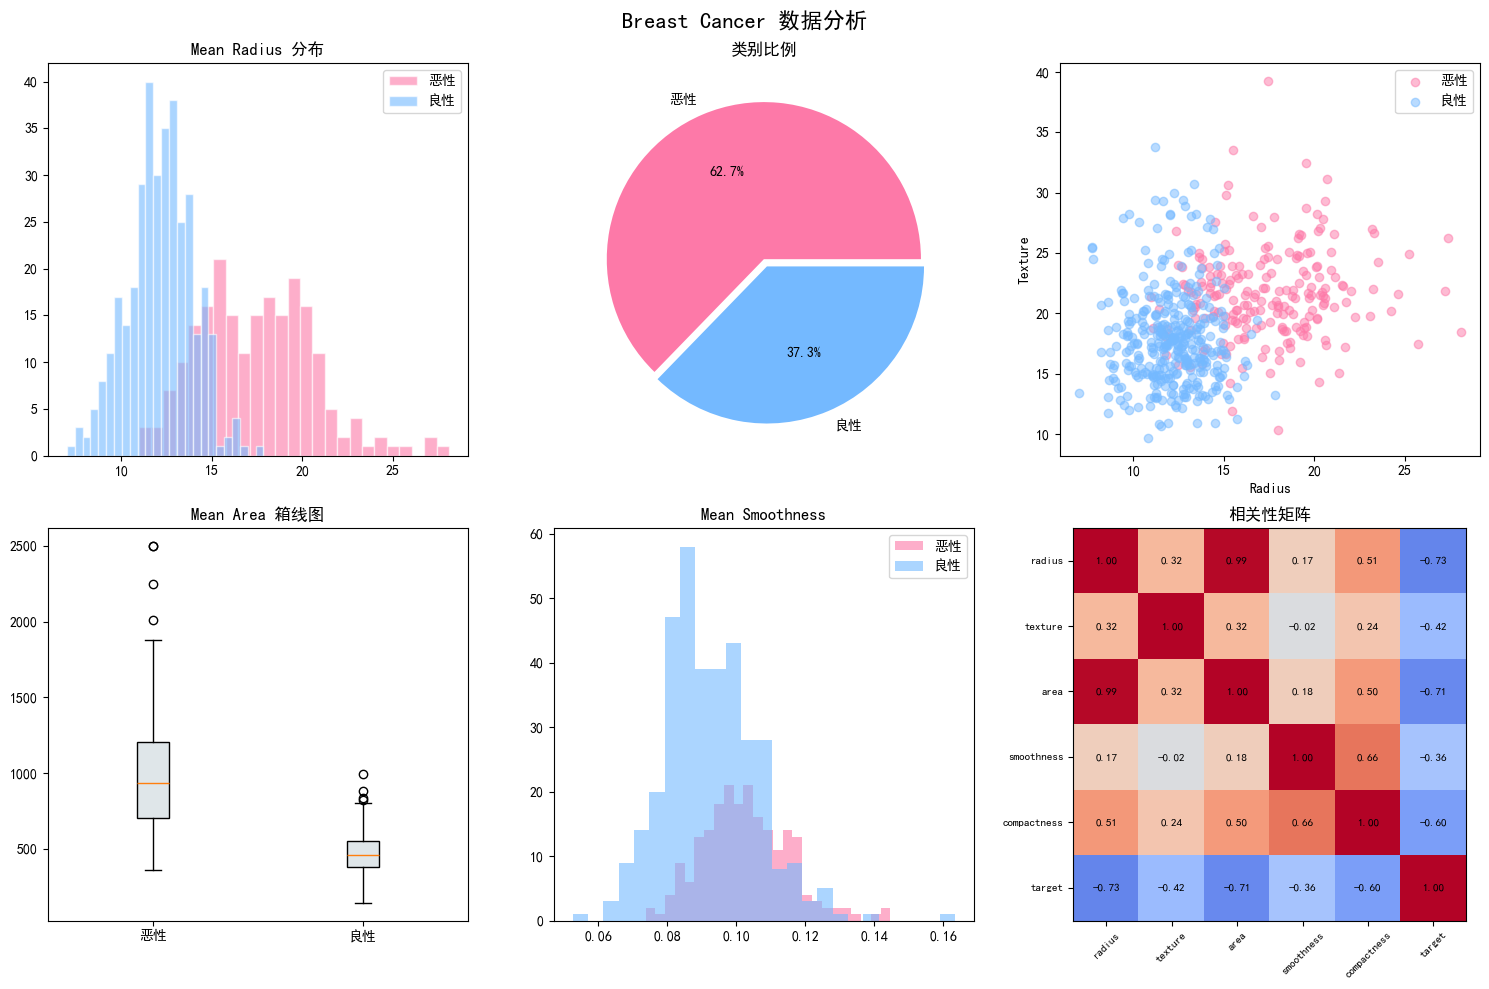

✅ 完成！请查看文件夹。
🤖 模型训练完成！
🎯 测试集准确率 (Accuracy): 0.9737

📊 分类报告 (精确率/召回率/F1分数):
              precision    recall  f1-score   support

          恶性       0.98      0.95      0.96        43
          良性       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
import os  # <--- 新增：用于处理文件路径

# --- 1. 设置中文字体 (防止乱码) ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False 

# --- 2. 准备数据 ---
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target 

# --- 3. 核心绘图代码 ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Breast Cancer 数据分析", fontsize=16, fontweight="bold")

# 图1: 半径分布
axes[0,0].hist(df[df["target"]==0]["mean radius"], bins=25, alpha=0.6, color="#fd79a8", label="恶性", edgecolor="white")
axes[0,0].hist(df[df["target"]==1]["mean radius"], bins=25, alpha=0.6, color="#74b9ff", label="良性", edgecolor="white")
axes[0,0].set_title("Mean Radius 分布"); axes[0,0].legend()

# 图2: 类别比例
counts = df["target"].value_counts()
axes[0,1].pie(counts, labels=["恶性", "良性"], autopct="%1.1f%%", colors=["#fd79a8", "#74b9ff"], explode=(0,0.05))
axes[0,1].set_title("类别比例")

# 图3: 散点图
axes[0,2].scatter(df[df["target"]==0]["mean radius"], df[df["target"]==0]["mean texture"], c="#fd79a8", alpha=0.5, label="恶性")
axes[0,2].scatter(df[df["target"]==1]["mean radius"], df[df["target"]==1]["mean texture"], c="#74b9ff", alpha=0.5, label="良性")
axes[0,2].set_xlabel("Radius"); axes[0,2].set_ylabel("Texture"); axes[0,2].legend()

# 图4: 箱线图
axes[1,0].boxplot([df[df["target"]==0]["mean area"], df[df["target"]==1]["mean area"]], tick_labels=["恶性", "良性"], patch_artist=True, boxprops=dict(facecolor="#dfe6e9"))
axes[1,0].set_title("Mean Area 箱线图")

# 图5: 平滑度分布
axes[1,1].hist(df[df["target"]==0]["mean smoothness"], bins=25, alpha=0.6, color="#fd79a8", label="恶性")
axes[1,1].hist(df[df["target"]==1]["mean smoothness"], bins=25, alpha=0.6, color="#74b9ff", label="良性")
axes[1,1].set_title("Mean Smoothness"); axes[1,1].legend()

# 图6: 相关性热图
keys = ["mean radius", "mean texture", "mean area", "mean smoothness", "mean compactness", "target"]
corr = df[keys].corr()
im = axes[1,2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
for i in range(len(keys)):
    for j in range(len(keys)):
        axes[1,2].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
axes[1,2].set_xticks(range(len(keys))); axes[1,2].set_yticks(range(len(keys)))
axes[1,2].set_xticklabels([k.replace("mean ","") for k in keys], rotation=45, fontsize=8)
axes[1,2].set_yticklabels([k.replace("mean ","") for k in keys], fontsize=8)
axes[1,2].set_title("相关性矩阵")

plt.tight_layout()

# --- 4. 关键修改：确保保存到代码所在目录 ---
# 获取当前脚本/Notebook 所在的绝对路径
script_dir = os.path.dirname(os.path.abspath("__file__")) 
# 拼接完整的保存路径
save_path = os.path.join(script_dir, "day1_analysis.png")

print(f"💾 正在保存图片到: {save_path}")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("✅ 完成！请查看文件夹。")


#模型训练准确性
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# --- 1. 准备特征(X)和标签(y) ---
X = df.drop(columns=['target'])  # 特征：除了标签以外的所有列
y = df['target']                 # 标签：0是恶性，1是良性

# --- 2. 划分训练集和测试集 (80% 训练, 20% 测试) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 3. 数据标准化 (逻辑回归对特征尺度非常敏感，这一步必不可少！) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # 在训练集上拟合并转换
X_test = scaler.transform(X_test)        # 在测试集上只做转换

# --- 4. 创建并训练逻辑回归模型 ---
model = LogisticRegression(max_iter=1000)  # 增加最大迭代次数防止不收敛
model.fit(X_train, y_train)

# --- 5. 模型预测与评估 ---
y_pred = model.predict(X_test)

print("🤖 模型训练完成！")
print(f"🎯 测试集准确率 (Accuracy): {model.score(X_test, y_test):.4f}")
print("\n📊 分类报告 (精确率/召回率/F1分数):")
print(classification_report(y_test, y_pred, target_names=['恶性', '良性']))

# 🎉 Day 1 完成!

## 今天学到的

| 工具 | 核心功能 |
|------|--------|
| NumPy | ndarray、广播、向量化 |
| Pandas | read_csv、info/describe、groupby、loc/iloc |
| Matplotlib | hist、scatter、boxplot、corr 热图 |

## 关键领悟

1. **向量化 = 快100倍** → 扔掉 for 循环
2. **广播** → NumPy 的超能力
3. **先看懂数据，再建模** → 图比数字直观10倍